In [1]:
#!/usr/bin/env python
# coding: utf-8

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import time
import pickle

In [2]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def load_and_preprocess_data(filepath):
    """Load and preprocess C-MAPSS data"""
    data = pd.read_csv(filepath, sep=' ', header=None)
    data = data.drop(columns=[26, 27])  # Remove empty columns
    
    # Add meaningful column names
    column_names = ['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
    data.columns = column_names
    
    return data

def find_constant_sensors(data, threshold=0.01):
    """Find sensors that have very little variation"""
    sensor_cols = [col for col in data.columns if col.startswith('sensor_')]
    constant_sensors = []
    
    print("Analyzing sensor variability...")
    for sensor in sensor_cols:
        sensor_std = data[sensor].std()
        sensor_range = data[sensor].max() - data[sensor].min()
        
        if sensor_std < threshold or sensor_range < threshold:
            constant_sensors.append(sensor)
            print(f"  {sensor}: std={sensor_std:.6f}, range={sensor_range:.6f} -> REMOVING")
    
    return constant_sensors

def create_rul_windows(engine_data, window_size=30, sensor_cols=None, has_rul=True):
    """Create sliding windows for an engine"""
    windows = []
    targets = []
    
    if len(engine_data) < window_size:
        return np.array([]), np.array([])
    
    # Use provided sensor columns
    if sensor_cols is None:
        sensor_cols = [col for col in engine_data.columns if col.startswith('sensor_')]
    
    for i in range(len(engine_data) - window_size + 1):
        window = engine_data[sensor_cols].iloc[i:i+window_size].values
        windows.append(window.flatten())
        
        if has_rul:
            target = engine_data['RUL'].iloc[i+window_size-1]
            targets.append(target)
    
    return np.array(windows), np.array(targets)

In [3]:
# =============================================================================
# MAIN PROCESSING
# =============================================================================

print("=== C-MAPSS IMPROVED BASELINE ===")

# 1. Load training data
print("\n1. Loading training data...")
train_data = load_and_preprocess_data('train_FD001.txt')
print(f"   Shape: {train_data.shape}")
print(f"   Engines: {train_data['engine_id'].nunique()}")

# 2. Remove constant sensors (based on training data only)
print("\n2. Removing constant/near-constant sensors...")
constant_sensors = find_constant_sensors(train_data, threshold=0.01)

if constant_sensors:
    print(f"   Removing {len(constant_sensors)} sensors: {constant_sensors}")
    train_data = train_data.drop(columns=constant_sensors)
else:
    print("   No constant sensors found")

remaining_sensors = [col for col in train_data.columns if col.startswith('sensor_')]
print(f"   Remaining: {len(remaining_sensors)} sensors")

# 3. Create RUL labels
print("\n3. Creating RUL labels...")
max_life = train_data.groupby('engine_id')['cycle'].max().reset_index()
max_life.columns = ['engine_id', 'max_life']
train_data = train_data.merge(max_life, on='engine_id')
train_data['RUL'] = train_data['max_life'] - train_data['cycle']
train_data['RUL'] = train_data['RUL'].clip(upper=125)
print(f"   RUL range: {train_data['RUL'].min()} to {train_data['RUL'].max()}")

# 4. Load and clean test data
print("\n4. Loading test data...")
test_data = load_and_preprocess_data('test_FD001.txt')
if constant_sensors:
    test_data = test_data.drop(columns=constant_sensors)
print(f"   Shape: {test_data.shape}")
print(f"   Engines: {test_data['engine_id'].nunique()}")

# Load true RUL
true_rul = pd.read_csv('RUL_FD001.txt', header=None, names=['true_RUL'])
true_rul['engine_id'] = range(1, len(true_rul) + 1)

# 5. Scale sensor data
print("\n5. Scaling sensor data...")
scale_columns = ['setting_1', 'setting_2', 'setting_3'] + remaining_sensors
scaler = StandardScaler()

# Fit on training, apply to both
train_data[scale_columns] = scaler.fit_transform(train_data[scale_columns])
test_data[scale_columns] = scaler.transform(test_data[scale_columns])
print("   Scaling completed")

# 6. Create training windows
print("\n6. Creating training windows...")
train_windows = []
train_targets = []

for engine_id in train_data['engine_id'].unique():
    engine_data = train_data[train_data['engine_id'] == engine_id]
    windows, targets = create_rul_windows(engine_data, window_size=30, 
                                        sensor_cols=remaining_sensors, has_rul=True)
    if len(windows) > 0:
        train_windows.append(windows)
        train_targets.append(targets)

X_train = np.vstack(train_windows)
y_train = np.concatenate(train_targets)
print(f"   Training windows: {X_train.shape}")
print(f"   Features per window: {len(remaining_sensors)} × 30 = {X_train.shape[1]}")

# 7. Create test windows (last window only)
print("\n7. Creating test windows...")
test_windows = []
test_engine_ids = []

for engine_id in test_data['engine_id'].unique():
    engine_data = test_data[test_data['engine_id'] == engine_id]
    
    if len(engine_data) >= 30:
        last_window = engine_data[remaining_sensors].iloc[-30:].values
        test_windows.append(last_window.flatten())
        test_engine_ids.append(engine_id)
    else:
        print(f"   Skipping engine {engine_id}: only {len(engine_data)} cycles")

X_test = np.array(test_windows)
test_engine_ids = np.array(test_engine_ids)
y_test = true_rul[true_rul['engine_id'].isin(test_engine_ids)]['true_RUL'].values

print(f"   Test windows: {X_test.shape}")
print(f"   Test engines processed: {len(test_engine_ids)}")

# 8. Train Random Forest
print("\n8. Training Random Forest...")
start_time = time.time()

rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)
train_time = time.time() - start_time

# 9. Make predictions and evaluate
print("\n9. Evaluating model...")
y_pred = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)

=== C-MAPSS IMPROVED BASELINE ===

1. Loading training data...
   Shape: (20631, 26)
   Engines: 100

2. Removing constant/near-constant sensors...
Analyzing sensor variability...
  sensor_1: std=0.000000, range=0.000000 -> REMOVING
  sensor_5: std=0.000000, range=0.000000 -> REMOVING
  sensor_6: std=0.001389, range=0.010000 -> REMOVING
  sensor_10: std=0.000000, range=0.000000 -> REMOVING
  sensor_16: std=0.000000, range=0.000000 -> REMOVING
  sensor_18: std=0.000000, range=0.000000 -> REMOVING
  sensor_19: std=0.000000, range=0.000000 -> REMOVING
   Removing 7 sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
   Remaining: 14 sensors

3. Creating RUL labels...
   RUL range: 0 to 125

4. Loading test data...
   Shape: (13096, 19)
   Engines: 100

5. Scaling sensor data...
   Scaling completed

6. Creating training windows...
   Training windows: (17731, 420)
   Features per window: 14 × 30 = 420

7. Creating test windows...
   Test windo

In [4]:
# =============================================================================
# RESULTS
# =============================================================================

print("\n" + "="*60)
print("IMPROVED C-MAPSS BASELINE RESULTS")
print("="*60)

print(f"Data Processing:")
print(f"  Removed {len(constant_sensors)} constant sensors")
print(f"  Applied StandardScaler to {len(remaining_sensors)} sensors + 3 settings")
print(f"  Used proper train/test split (no data leakage)")

print(f"\nPerformance:")
print(f"  R² Score: {r2:.4f} ({r2*100:.2f}%)")
print(f"  RMSE: {rmse:.2f} cycles")
print(f"  MAE: {mae:.2f} cycles")
print(f"  Training time: {train_time:.3f}s")

print(f"\nData Summary:")
print(f"  Training samples: {len(X_train):,}")
print(f"  Test samples: {len(X_test):,}")
print(f"  Features per sample: {X_train.shape[1]:,}")

print(f"\nSample Predictions:")
for i in range(min(10, len(y_test))):
    error = abs(y_pred[i] - y_test[i])
    print(f"  Engine {test_engine_ids[i]:3d}: Pred={y_pred[i]:6.1f}, True={y_test[i]:6.1f}, Error={error:5.1f}")

# Feature importance
feature_importance = rf_model.feature_importances_
top_features = sorted(enumerate(feature_importance), key=lambda x: x[1], reverse=True)[:10]

print(f"\nTop 10 Features:")
for i, (feature_idx, importance) in enumerate(top_features):
    sensor_idx = feature_idx % len(remaining_sensors)
    timestep = feature_idx // len(remaining_sensors)
    sensor_name = remaining_sensors[sensor_idx]
    print(f"  #{i+1}: {sensor_name} at timestep {timestep+1:2d} - {importance:.4f} ({importance*100:.2f}%)")

# Error analysis
errors = y_pred - y_test
print(f"\nError Analysis:")
print(f"  Mean error: {np.mean(errors):6.2f}")
print(f"  Std error:  {np.std(errors):6.2f}")
print(f"  Max error:  {np.max(np.abs(errors)):6.1f}")
print(f"  Large errors (>20): {np.sum(np.abs(errors) > 20)}/{len(errors)} ({np.sum(np.abs(errors) > 20)/len(errors)*100:.1f}%)")


IMPROVED C-MAPSS BASELINE RESULTS
Data Processing:
  Removed 7 constant sensors
  Applied StandardScaler to 14 sensors + 3 settings
  Used proper train/test split (no data leakage)

Performance:
  R² Score: 0.8123 (81.23%)
  RMSE: 18.00 cycles
  MAE: 13.37 cycles
  Training time: 62.230s

Data Summary:
  Training samples: 17,731
  Test samples: 100
  Features per sample: 420

Sample Predictions:
  Engine   1: Pred= 116.2, True= 112.0, Error=  4.2
  Engine   2: Pred= 110.4, True=  98.0, Error= 12.4
  Engine   3: Pred=  63.8, True=  69.0, Error=  5.2
  Engine   4: Pred=  94.7, True=  82.0, Error= 12.7
  Engine   5: Pred=  98.2, True=  91.0, Error=  7.2
  Engine   6: Pred= 103.0, True=  93.0, Error= 10.0
  Engine   7: Pred= 101.5, True=  91.0, Error= 10.5
  Engine   8: Pred=  98.0, True=  95.0, Error=  3.0
  Engine   9: Pred= 107.8, True= 111.0, Error=  3.2
  Engine  10: Pred=  95.9, True=  96.0, Error=  0.1

Top 10 Features:
  #1: sensor_11 at timestep 30 - 0.0353 (3.53%)
  #2: sensor_1

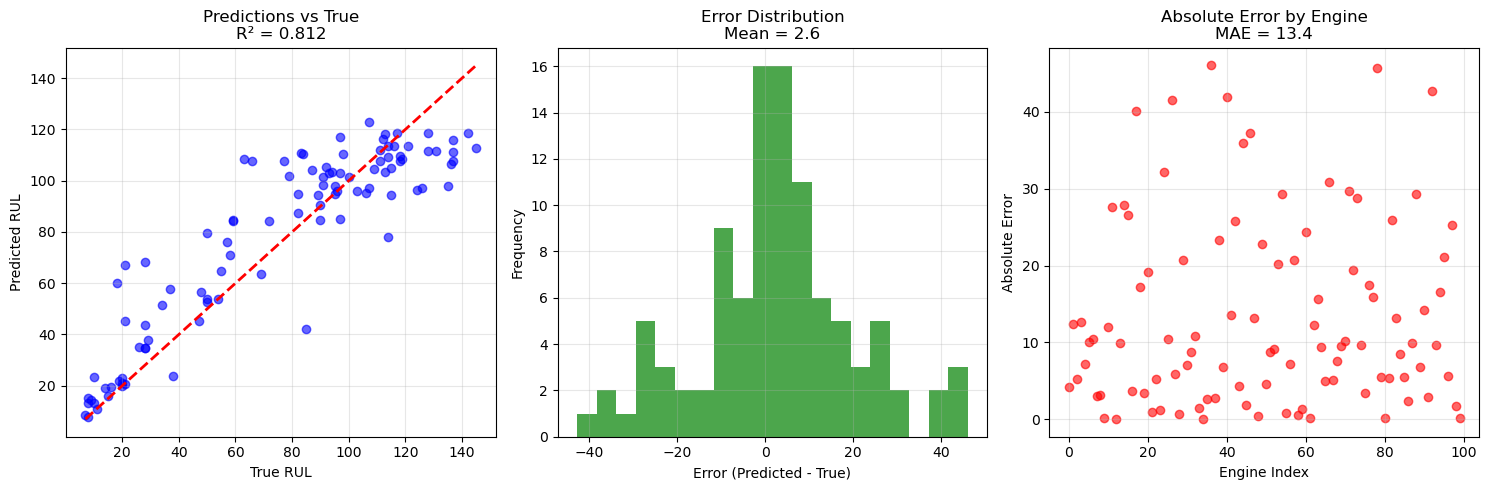

In [5]:
# =============================================================================
# VISUALIZATION
# =============================================================================

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('True RUL')
plt.ylabel('Predicted RUL')
plt.title(f'Predictions vs True\nR² = {r2:.3f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(errors, bins=20, alpha=0.7, color='green')
plt.xlabel('Error (Predicted - True)')
plt.ylabel('Frequency')
plt.title(f'Error Distribution\nMean = {np.mean(errors):.1f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(range(len(y_test)), np.abs(errors), alpha=0.6, color='red')
plt.xlabel('Engine Index')
plt.ylabel('Absolute Error')
plt.title(f'Absolute Error by Engine\nMAE = {mae:.1f}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# =============================================================================
# SAVE FOR LLM INTEGRATION
# =============================================================================

print(f"\nSaving data for LLM integration...")

np.save('X_train_improved.npy', X_train)
np.save('y_train_improved.npy', y_train)
np.save('X_test_improved.npy', X_test)
np.save('y_test_improved.npy', y_test)
np.save('y_pred_improved.npy', y_pred)
np.save('test_engine_ids_improved.npy', test_engine_ids)
np.save('remaining_sensors.npy', np.array(remaining_sensors))

with open('sensor_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Files saved:")
print(f"  X_train_improved.npy: {X_train.shape}")
print(f"  X_test_improved.npy: {X_test.shape}")
print(f"  remaining_sensors.npy: {len(remaining_sensors)} sensors")
print(f"  sensor_scaler.pkl: StandardScaler fitted on training data")


Saving data for LLM integration...
Files saved:
  X_train_improved.npy: (17731, 420)
  X_test_improved.npy: (100, 420)
  remaining_sensors.npy: 14 sensors
  sensor_scaler.pkl: StandardScaler fitted on training data


In [7]:
# ===== Cell A: Build per-engine summaries from last 30 cycles (FD001) =====
import os, re, json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Optional
from sklearn.preprocessing import StandardScaler
from numpy.linalg import lstsq

DATA_DIR = "."
WINDOW = 30
TOL_CONST = 1e-6

def _read_cmapss(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=r"\s+", header=None)
    if df.shape[1] > 26:
        df = df.iloc[:, :26]
    df.columns = ["engine_id","cycle","setting_1","setting_2","setting_3"] + [f"sensor_{i}" for i in range(1,22)]
    return df

def load_fd001(data_dir="."):
    train = _read_cmapss(os.path.join(data_dir, "train_FD001.txt"))
    test  = _read_cmapss(os.path.join(data_dir, "test_FD001.txt"))
    tru   = pd.read_csv(os.path.join(data_dir, "RUL_FD001.txt"), header=None)[0]
    tru.index = pd.Index(range(1, len(tru)+1), name="engine_id")
    return train, test, tru

def sensor_cols(df): 
    return [c for c in df.columns if c.startswith("sensor_")]

def drop_flat_sensors(train_df, tol=TOL_CONST):
    flats = []
    for c in sensor_cols(train_df):
        if np.nanstd(train_df[c].values) <= tol:
            flats.append(c)
    keep = [c for c in train_df.columns if c not in flats]
    return train_df[keep].copy(), flats

def fit_scaler_on_train(train_df):
    cols = ["setting_1","setting_2","setting_3"] + sensor_cols(train_df)
    sc = StandardScaler()
    sc.fit(train_df[cols])
    return sc, cols

def zscore_using_train(train_df, test_df, scaler, cols):
    train_df_s = train_df.copy()
    test_df_s  = test_df.copy()
    train_df_s[cols] = scaler.transform(train_df[cols])
    test_df_s[cols]  = scaler.transform(test_df[cols])
    return train_df_s, test_df_s

def window_last_block(df, eng, window=30, include_settings=False):
    d = df[df.engine_id == eng].sort_values("cycle")
    if len(d) < window:
        return None, None
    cols = sensor_cols(d)
    if include_settings:
        cols = ["setting_1","setting_2","setting_3"] + cols
    block = d[cols].values[-window:]
    return block, cols

def slope_1d(y):
    """Return slope per cycle using least squares (x = 0..n-1)."""
    n = len(y)
    x = np.arange(n)
    A = np.vstack([x, np.ones_like(x)]).T
    m, b = lstsq(A, y, rcond=None)[0]
    return m

def summarize_block(block: np.ndarray, cols: List[str]):
    """Compute summary stats per column over the window."""
    block = np.asarray(block)
    means = np.nanmean(block, axis=0)
    stds  = np.nanstd(block, axis=0)
    mins  = np.nanmin(block, axis=0)
    maxs  = np.nanmax(block, axis=0)
    slopes = np.array([slope_1d(block[:, j]) for j in range(block.shape[1])])
    summary = pd.DataFrame({
        "feature": cols,
        "mean": means,
        "std": stds,
        "min": mins,
        "max": maxs,
        "slope": slopes
    })
    return summary

def make_llm_summary_text(summary_df: pd.DataFrame, top_k:int=6) -> str:
    """
    Create a short, human-readable summary emphasizing largest anomalies/trends.
    Uses |z-mean| and |slope| to pick signals.
    """
    # Heuristic scores
    s = summary_df.copy()
    s["z_abs_mean"] = s["mean"].abs()
    s["abs_slope"]  = s["slope"].abs()
    # rank by combined score (weight z-mean slightly more than slope)
    s["rank_score"] = 0.6*s["z_abs_mean"] + 0.4*s["abs_slope"]
    s = s.sort_values("rank_score", ascending=False)
    picks = s.head(top_k)

    parts = []
    for _, r in picks.iterrows():
        # compress name for readability
        name = r["feature"].replace("setting_", "Set").replace("sensor_", "S")
        parts.append(f"{name}: z-mean={r['mean']:+.2f}, slope={r['slope']:+.03f}/cycle, σ={r['std']:.2f}")
    return "; ".join(parts)

# ---- Run the pipeline on FD001 ----
train_df, test_df, true_rul = load_fd001(DATA_DIR)

# Drop flats on train only
train_df_nf, flats = drop_flat_sensors(train_df)
# Align test to same columns
test_df_nf = test_df[[c for c in test_df.columns if c in train_df_nf.columns]].copy()

# Fit scaler on train; z-score both
scaler, scale_cols = fit_scaler_on_train(train_df_nf)
train_z, test_z = zscore_using_train(train_df_nf, test_df_nf, scaler, scale_cols)

# Build summary table per test engine (last 30 cycles)
rows = []
for eng in sorted(test_z["engine_id"].unique()):
    block, cols = window_last_block(test_z, eng, window=WINDOW, include_settings=False)
    if block is None:
        continue
    summary = summarize_block(block, cols)
    text = make_llm_summary_text(summary, top_k=6)
    rows.append({
        "engine_id": eng,
        "llm_summary": text,
        "top_features_json": summary.sort_values("mean", key=np.abs, ascending=False).head(10).to_json(orient="records")
    })

summ_df = pd.DataFrame(rows).set_index("engine_id").sort_index()
summ_df.head(10)


,llm_summary,top_features_json
engine_id,,
1,"S17: z-mean=-0.95, slope=+0.012/cycle, σ=0.58;...","[{""feature"":""sensor_17"",""mean"":-0.9538943778,""..."
2,"S14: z-mean=-0.78, slope=-0.006/cycle, σ=0.16;...","[{""feature"":""sensor_14"",""mean"":-0.7788466383,""..."
3,"S14: z-mean=-0.77, slope=+0.002/cycle, σ=0.15;...","[{""feature"":""sensor_14"",""mean"":-0.76661468,""st..."
4,"S9: z-mean=-0.58, slope=+0.010/cycle, σ=0.21; ...","[{""feature"":""sensor_9"",""mean"":-0.5827705848,""s..."
5,"S14: z-mean=-0.66, slope=-0.005/cycle, σ=0.16;...","[{""feature"":""sensor_14"",""mean"":-0.6601442204,""..."
6,"S9: z-mean=-0.57, slope=-0.007/cycle, σ=0.18; ...","[{""feature"":""sensor_9"",""mean"":-0.5703473869,""s..."
7,"S8: z-mean=-0.95, slope=-0.009/cycle, σ=0.41; ...","[{""feature"":""sensor_8"",""mean"":-0.9483621157,""s..."
8,"S9: z-mean=-0.72, slope=+0.003/cycle, σ=0.18; ...","[{""feature"":""sensor_9"",""mean"":-0.7193200964,""s..."
9,"S14: z-mean=-0.66, slope=+0.004/cycle, σ=0.20;...","[{""feature"":""sensor_14"",""mean"":-0.6593578802,""..."


In [8]:
%pip install -U "openai>=1.40.0"

import openai, sys
print("openai version:", openai.__version__)
print("python:", sys.version)

Note: you may need to restart the kernel to use updated packages.
openai version: 1.107.2
python: 3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]


In [14]:
import os
os.environ["OPENAI_API_KEY"] = "INSERT_SECRET_KEY"

In [15]:
# ===== Fixed LLM Risk Scoring with OpenAI API =====

!pip install --quiet openai

import os, json, time
import pandas as pd
import numpy as np
from openai import OpenAI

# 1) Check API key
if "OPENAI_API_KEY" not in os.environ or not os.environ["OPENAI_API_KEY"]:
    raise RuntimeError("Set OPENAI_API_KEY in your environment before running this cell.")

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# 2) Define JSON schema for structured outputs
risk_assessment_schema = {
    "name": "risk_assessment",
    "schema": {
        "type": "object",
        "properties": {
            "risk_score": {
                "type": "number", 
                "minimum": 0.0, 
                "maximum": 1.0,
                "description": "Risk score from 0 (low risk) to 1 (high risk)"
            },
            "lead_time_cycles": {
                "type": "integer", 
                "minimum": 0,
                "description": "Estimated cycles until failure"
            },
            "rationale": {
                "type": "string", 
                "maxLength": 600,
                "description": "Brief explanation of the assessment"
            }
        },
        "required": ["risk_score", "lead_time_cycles", "rationale"],
        "additionalProperties": False
    },
    "strict": True
}

# 3) System prompt for the LLM
SYSTEM_PROMPT = """You are an expert in turbofan engine failure prediction and remaining useful life (RUL) analysis.

Your task is to assess failure risk from sensor trend summaries of the last 30 cycles of engine operation.

Key guidelines:
- risk_score: 0.0 = very low risk, 1.0 = imminent failure
- lead_time_cycles: your best estimate of cycles until failure
- Focus on recent trends and degradation patterns
- Consider sensor combinations that indicate different failure modes
- If evidence is weak or conflicting, be conservative (lower risk, higher lead time)
- This is FD001 data: single operating condition, HPC degradation failure mode

Return your assessment as JSON following the provided schema."""

# 4) Function to build user messages
def build_user_message(engine_id: int, summary_text: str, rf_prediction: float = None) -> str:
    base_msg = f"""Engine {engine_id} Analysis:

Last 30 cycles sensor summary:
{summary_text}"""
    
    if rf_prediction is not None:
        base_msg += f"\n\nRandom Forest baseline prediction: {rf_prediction:.1f} cycles RUL"
    
    base_msg += "\n\nPlease provide your risk assessment as JSON."
    
    return base_msg

# 5) Function to call OpenAI API with error handling
def get_llm_risk_assessment(engine_id, summary_text, rf_prediction=None, max_retries=3):
    """Call OpenAI API with retries and error handling"""
    
    user_message = build_user_message(engine_id, summary_text, rf_prediction)
    
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",  # Using correct model name
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": user_message}
                ],
                response_format={
                    "type": "json_schema", 
                    "json_schema": risk_assessment_schema
                },
                temperature=0.1,  # Low temperature for consistent technical analysis
                max_tokens=800
            )
            
            # Parse the JSON response
            content = response.choices[0].message.content
            payload = json.loads(content)
            
            return {
                "risk_score": float(payload.get("risk_score", 0.0)),
                "lead_time_cycles": int(payload.get("lead_time_cycles", 999)),
                "rationale": payload.get("rationale", ""),
                "api_success": True
            }
            
        except json.JSONDecodeError as e:
            print(f"Engine {engine_id}, attempt {attempt+1}: JSON parse error - {e}")
            if attempt == max_retries - 1:
                return {
                    "risk_score": 0.0,
                    "lead_time_cycles": 999,
                    "rationale": f"JSON_PARSE_ERROR: {e}",
                    "api_success": False
                }
        
        except Exception as e:
            print(f"Engine {engine_id}, attempt {attempt+1}: API error - {e}")
            if attempt == max_retries - 1:
                return {
                    "risk_score": 0.0,
                    "lead_time_cycles": 999,
                    "rationale": f"API_ERROR: {e}",
                    "api_success": False
                }
        
        # Wait before retry
        time.sleep(1.0)
    
    return None

# 6) Example of how to use it (you'll need to replace with your actual data)
# Assuming you have a DataFrame with summaries called 'summ_df'

def run_llm_analysis(summ_df, rf_predictions=None):
    """Run LLM analysis on all engines"""
    
    results = []
    
    print(f"Processing {len(summ_df)} engines with LLM analysis...")
    
    for i, (eng_id, row) in enumerate(summ_df.iterrows()):
        print(f"Processing Engine {eng_id} ({i+1}/{len(summ_df)})")
        
        # Get RF prediction if available
        rf_pred = rf_predictions[i] if rf_predictions is not None else None
        
        # Get LLM assessment
        result = get_llm_risk_assessment(
            engine_id=eng_id,
            summary_text=row['llm_summary'],  # Adjust column name as needed
            rf_prediction=rf_pred
        )
        
        if result:
            result['engine_id'] = eng_id
            results.append(result)
        
        # Small delay to be nice to the API
        time.sleep(0.2)
    
    # Create DataFrame with results
    llm_df = pd.DataFrame(results).set_index('engine_id').sort_index()
    
    print(f"\nCompleted! Success rate: {llm_df['api_success'].sum()}/{len(llm_df)}")
    
    return llm_df

# 7) If you want to test with a single example first:
def test_single_engine():
    """Test with a single engine to make sure everything works"""
    
    # Example summary (replace with your actual data)
    test_summary = """
    Sensor trends over last 30 cycles:
    - sensor_7 (temperature): gradual increase from 0.45 to 0.78 (concerning upward trend)
    - sensor_11 (vibration): stable around 0.23 until cycle 25, then spike to 0.67
    - sensor_4 (pressure): steady decline from 0.89 to 0.56
    - Cross-sensor pattern: temperature rise preceded vibration spike by 5 cycles
    """
    
    result = get_llm_risk_assessment(
        engine_id=999, 
        summary_text=test_summary, 
        rf_prediction=45.5
    )
    
    print("Test result:")
    print(json.dumps(result, indent=2))
    
    return result

#Uncomment to test:
test_result = test_single_engine()

Test result:
{
  "risk_score": 0.7,
  "lead_time_cycles": 30,
  "rationale": "The analysis indicates a concerning upward trend in temperature and a significant spike in vibration, which are indicative of potential HPC degradation. The steady decline in pressure further supports the risk of failure. The cross-sensor pattern shows that the temperature rise preceded the vibration spike, suggesting a correlation that could indicate worsening conditions. Given these trends, while the Random Forest prediction suggests a longer RUL, the recent sensor behaviors warrant a higher risk score and a conservative estimate of lead time.",
  "api_success": true
}
